# Explore Muon Theoretical Lifetime in Argon
### --Created by Shu, 20250417

#### Doule exponential fitting:

Remark: Based on calculation showed in slides m_202505_1st
Remark: For the fitting function, we exepct N1/N2 should be 1/1.2 (Here is the 'pdf')


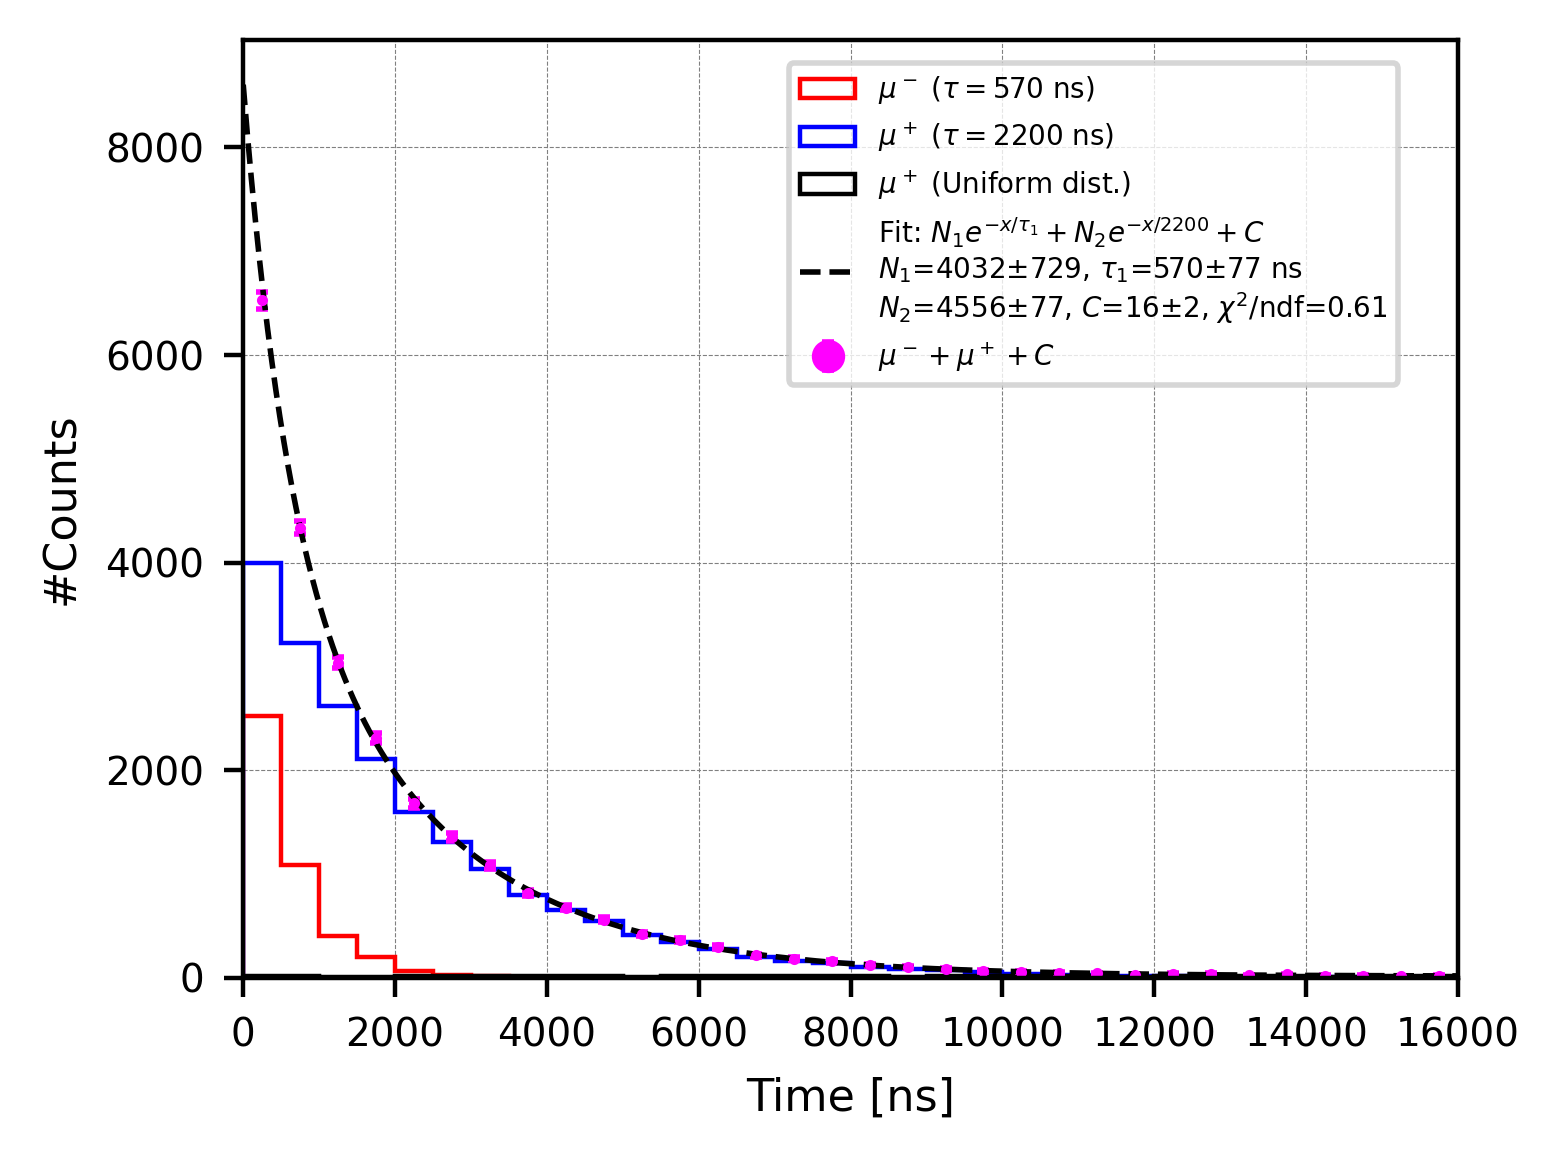


Fitted parameters:
  N1    = 4031.7 ± 728.8
  tau1  = 570 ± 77 ns
  N2    = 4556.4 ± 77.0
  C     = 16.2 ± 1.6
  Chi² / ndf = 15.8 / 26 = 0.61

Bin Center [ns]   Counts   Error
     250.0        6526     80.78
     750.0        4337     65.86
    1250.0        3036     55.10
    1750.0        2314     48.10
    2250.0        1681     41.00
    2750.0        1359     36.86
    3250.0        1083     32.91
    3750.0         820     28.64
    4250.0         676     26.00
    4750.0         562     23.71
    5250.0         423     20.57
    5750.0         362     19.03
    6250.0         295     17.18
    6750.0         218     14.76
    7250.0         184     13.56
    7750.0         160     12.65
    8250.0         125     11.18
    8750.0         101     10.05
    9250.0          89      9.43
    9750.0          69      8.31
   10250.0          61      7.81
   10750.0          51      7.14
   11250.0          45      6.71
   11750.0          31      5.57
   12250.0          37      6.

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Generate samples------------------------------------------
np.random.seed(42)

# Define time constants (in ns)
tau_A = 570   # ns
tau_B = 2200  # ns

# Generate samples--------
n_B = 20000
n_A = int(np.floor(n_B*0.21667)) 
samples_A = np.random.exponential(scale=tau_A, size=n_A)
samples_B = np.random.exponential(scale=tau_B, size=n_B)
n_C = 500  # for example
samples_C = np.random.uniform(0, 16000, n_C)


print("Remark: Based on calculation showed in slides m_202505_1st")
print("Remark: For the fitting function, we exepct N1/N2 should be 1/1.2 (Here is the 'pdf')")



# Plot the histograms------------------------------------
plt.figure(figsize=(4, 3), dpi=400)

# Define a common bin width
bin_width = 500  # ns
range_min = 0
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Compute histogram values
hist_A, bin_edges_A = np.histogram(samples_A, bins=bins, range=(range_min, range_max))
hist_B, bin_edges_B = np.histogram(samples_B, bins=bins, range=(range_min, range_max))
hist_C, bin_edges_C = np.histogram(samples_C, bins=bins, range=(range_min, range_max))

# Sum of all histograms
sum_hist = hist_A + hist_B + hist_C
bin_centers = (bin_edges_A[:-1] + bin_edges_A[1:]) / 2
sum_err = np.sqrt(sum_hist)

# Define new fitting function with offset C
def double_exp_decay(x, N1, tau1, N2, C):
    return N1 * np.exp(-x / tau1) + N2 * np.exp(-x / 2200) + C

# Mask bins with zero counts within the range [500, 15500]
mask = (bin_centers >= 500) & (bin_centers <= 15500) & (sum_hist > 0)
fit_x = bin_centers[mask]
fit_y = sum_hist[mask]
fit_err = sum_err[mask]

# Initial guess for parameters
initial_guess = [2000, 500, 8000, 0]  # N1, tau1, N2, C
popt, pcov = curve_fit(double_exp_decay, fit_x, fit_y, p0=initial_guess, sigma=fit_err, absolute_sigma=True)
N1_fit, tau1_fit, N2_fit, C_fit = popt
N1_err, tau1_err, N2_err, C_err = np.sqrt(np.diag(pcov))

# Compute chi-squared---------------
fit_model = double_exp_decay(fit_x, *popt)
chi2 = np.sum(((fit_y - fit_model) / fit_err) ** 2)
ndf = len(fit_y) - len(popt)
chi2_ndf = chi2 / ndf

# Drawing of initial plots----------
plt.hist(samples_A, bins=bins, histtype='step', color='red', linewidth=0.8, label='$\\mu^-$ ($\\tau = 570$ ns)')
plt.hist(samples_B, bins=bins, histtype='step', color='blue', linewidth=0.8, label='$\\mu^+$ ($\\tau = 2200$ ns)')
plt.hist(samples_C, bins=bins, histtype='step', color='black', linewidth=0.8, label='$\\mu^+$ (Uniform dist.)')
plt.errorbar(bin_centers, sum_hist, yerr=sum_err, fmt='o', color='magenta',
             markersize=1, elinewidth=0.5, capsize=1.0, label='$\\mu^- + \\mu^+ + C$')

# Plot the fitted curve-------------
x_fit_line = np.linspace(0, 16000, 300)
y_fit_line = double_exp_decay(x_fit_line, *popt)
plt.plot(x_fit_line, y_fit_line, 'k--', linewidth=1.0,
         label=f'Fit: $N_1 e^{{-x/\\tau_1}} + N_2 e^{{-x/2200}} + C$\n'
               f'$N_1$={N1_fit:.0f}±{N1_err:.0f}, $\\tau_1$={tau1_fit:.0f}±{tau1_err:.0f} ns\n'
               f'$N_2$={N2_fit:.0f}±{N2_err:.0f}, $C$={C_fit:.0f}±{C_err:.0f}, $\\chi^2$/ndf={chi2_ndf:.2f}')

# Axes settings-------------------
plt.xlim(0, 16000)
#plt.ylim(0.1, 10000)
#plt.yscale('log')
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=8, markerscale=5, ncol=1, prop={'size': 5})
plt.tight_layout()
plt.show()

# Print fit results----------
print(f"\nFitted parameters:")
print(f"  N1    = {N1_fit:.1f} ± {N1_err:.1f}")
print(f"  tau1  = {tau1_fit:.0f} ± {tau1_err:.0f} ns")
print(f"  N2    = {N2_fit:.1f} ± {N2_err:.1f}")
print(f"  C     = {C_fit:.1f} ± {C_err:.1f}")
print(f"  Chi² / ndf = {chi2:.1f} / {ndf} = {chi2_ndf:.2f}")

# Print bin center, count, and error----------
print("\nBin Center [ns]   Counts   Error")
for center, count, error in zip(bin_centers, sum_hist, sum_err):
    print(f"{center:10.1f}      {count:6d}   {error:7.2f}")


<br />
<br />
<br />

#### Single exponential fitting:

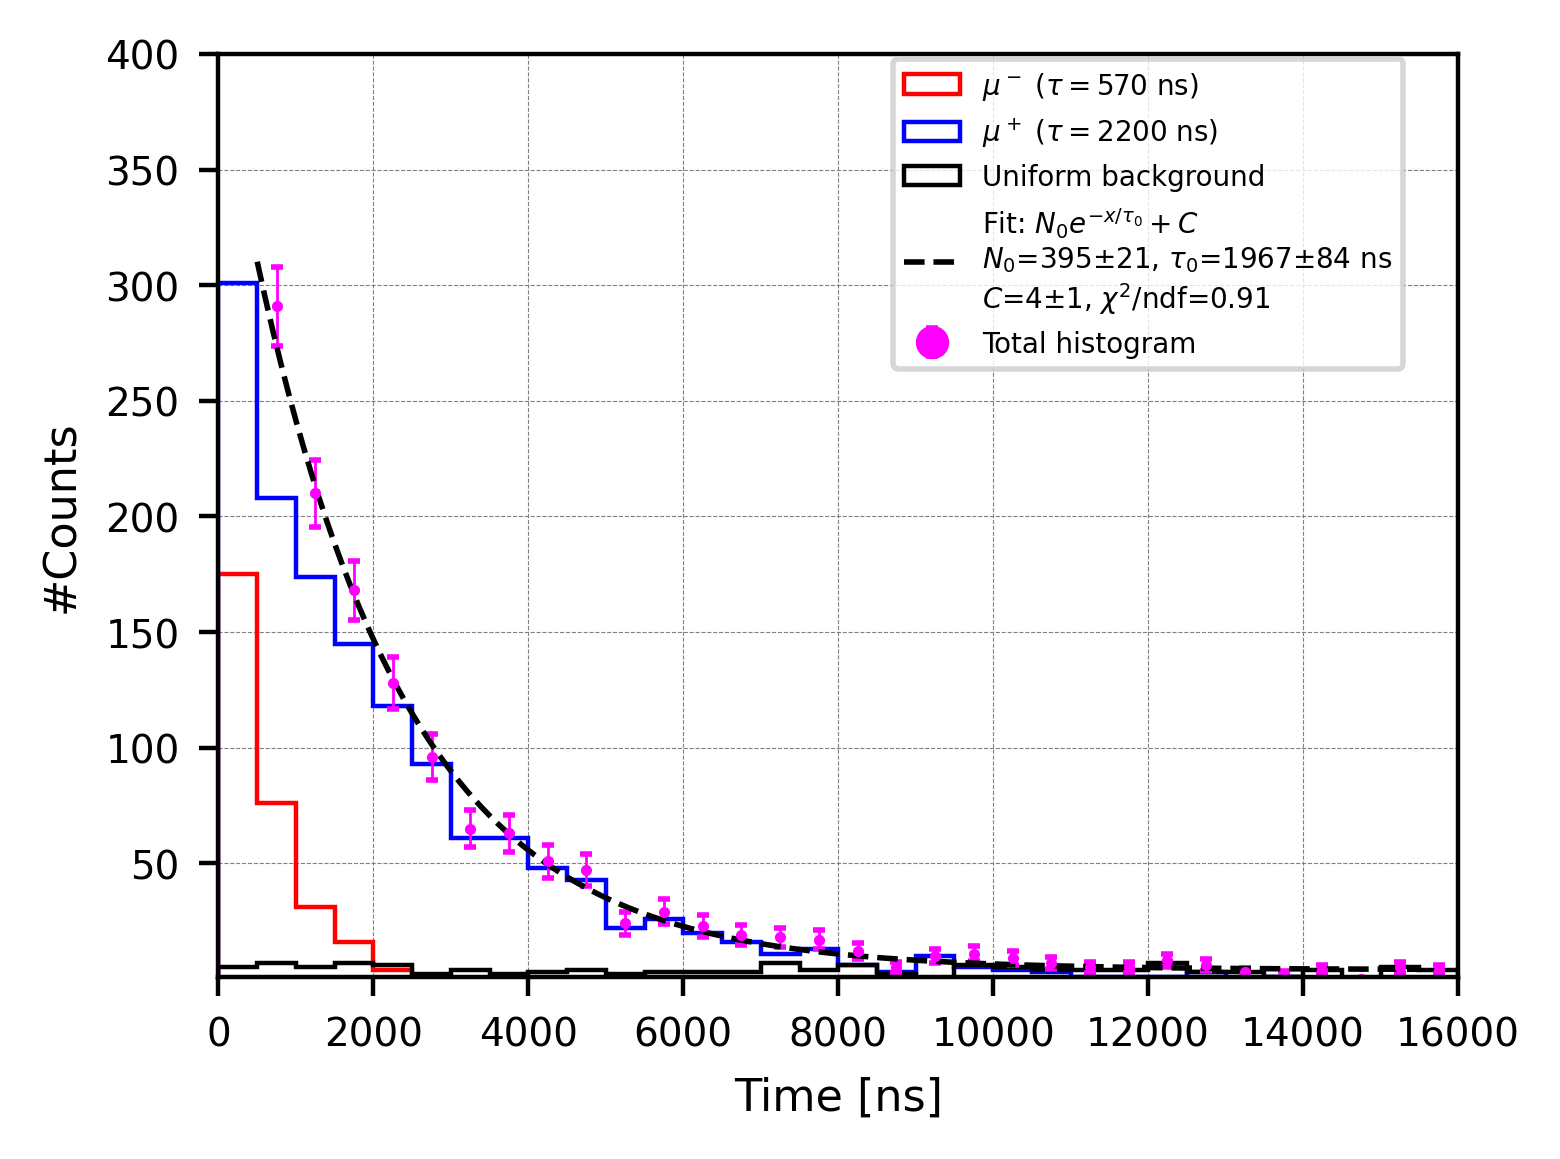


Fitted parameters:
  N0    = 394.7 ± 21.4
  tau0  = 1967 ± 84 ns
  C     = 4.0 ± 0.7
  Chi² / ndf = 23.6 / 26 = 0.91

Bin Center [ns]   Counts   Error
     250.0         481     21.93
     750.0         291     17.06
    1250.0         210     14.49
    1750.0         168     12.96
    2250.0         128     11.31
    2750.0          96      9.80
    3250.0          65      8.06
    3750.0          63      7.94
    4250.0          51      7.14
    4750.0          47      6.86
    5250.0          24      4.90
    5750.0          29      5.39
    6250.0          23      4.80
    6750.0          19      4.36
    7250.0          18      4.24
    7750.0          17      4.12
    8250.0          12      3.46
    8750.0           5      2.24
    9250.0          10      3.16
    9750.0          11      3.32
   10250.0           9      3.00
   10750.0           7      2.65
   11250.0           5      2.24
   11750.0           5      2.24
   12250.0           8      2.83
   12750.0           6 

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Generate samples------------------------------------------
np.random.seed(42)

# Define time constants (in ns)
tau_A = 570   # ns
tau_B = 2200  # ns

# Generate samples--------
#n_A = 350
n_B = 1400
n_A = int(np.floor(n_B*0.21667)) 
samples_A = np.random.exponential(scale=tau_A, size=n_A)
samples_B = np.random.exponential(scale=tau_B, size=n_B)
n_C = 125  # for example
samples_C = np.random.uniform(0, 16000, n_C)

# Plot the histograms------------------------------------
plt.figure(figsize=(4, 3), dpi=400)

# Define a common bin width
bin_width = 500  # ns
range_min = 0
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Compute histogram values
hist_A, bin_edges_A = np.histogram(samples_A, bins=bins, range=(range_min, range_max))
hist_B, bin_edges_B = np.histogram(samples_B, bins=bins, range=(range_min, range_max))
hist_C, bin_edges_C = np.histogram(samples_C, bins=bins, range=(range_min, range_max))

# Sum of all histograms
sum_hist = hist_A + hist_B + hist_C
bin_centers = (bin_edges_A[:-1] + bin_edges_A[1:]) / 2
sum_err = np.sqrt(sum_hist)

# Define the fitting function
def exp_func(t, N0, tau0, C):
    return N0 * np.exp(-t / tau0) + C

# Fit only within [500, 15500] and where counts > 0
fit_mask = (bin_centers >= 500) & (bin_centers <= 15500) & (sum_hist > 0)
fit_x = bin_centers[fit_mask]
fit_y = sum_hist[fit_mask]
fit_err = sum_err[fit_mask]

# Initial guess for parameters
initial_guess = [8000, 1000, 100]  # N0, tau0, C
popt, pcov = curve_fit(exp_func, fit_x, fit_y, p0=initial_guess, sigma=fit_err, absolute_sigma=True)
N0_fit, tau0_fit, C_fit = popt
N0_err, tau0_err, C_err = np.sqrt(np.diag(pcov))

# Compute chi-squared---------------
fit_model = exp_func(fit_x, *popt)
chi2 = np.sum(((fit_y - fit_model) / fit_err) ** 2)
ndf = len(fit_y) - len(popt)
chi2_ndf = chi2 / ndf

# Draw histograms of components and total
plt.hist(samples_A, bins=bins, histtype='step', color='red', linewidth=0.8, label='$\\mu^-$ ($\\tau = 570$ ns)')
plt.hist(samples_B, bins=bins, histtype='step', color='blue', linewidth=0.8, label='$\\mu^+$ ($\\tau = 2200$ ns)')
plt.hist(samples_C, bins=bins, histtype='step', color='black', linewidth=0.8, label='Uniform background')
plt.errorbar(bin_centers, sum_hist, yerr=sum_err, fmt='o', color='magenta',
             markersize=1, elinewidth=0.5, capsize=1.0, label='Total histogram')

# Plot the fitted curve in [500, 15500] only
x_fit_line = np.linspace(500, 15500, 300)
y_fit_line = exp_func(x_fit_line, *popt)
plt.plot(x_fit_line, y_fit_line, 'k--', linewidth=1.0,
         label=f'Fit: $N_0 e^{{-x/\\tau_0}} + C$\n'
               f'$N_0$={N0_fit:.0f}±{N0_err:.0f}, $\\tau_0$={tau0_fit:.0f}±{tau0_err:.0f} ns\n'
               f'$C$={C_fit:.0f}±{C_err:.0f}, $\\chi^2$/ndf={chi2_ndf:.2f}')

# Axes settings-------------------
plt.xlim(0, 16000)
plt.ylim(0.9, 400)
#plt.yscale('log')
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.75, 1.01), fontsize=8, markerscale=5, ncol=1, prop={'size': 5})
plt.tight_layout()
plt.show()

# Print fit results----------
print(f"\nFitted parameters:")
print(f"  N0    = {N0_fit:.1f} ± {N0_err:.1f}")
print(f"  tau0  = {tau0_fit:.0f} ± {tau0_err:.0f} ns")
print(f"  C     = {C_fit:.1f} ± {C_err:.1f}")
print(f"  Chi² / ndf = {chi2:.1f} / {ndf} = {chi2_ndf:.2f}")

# Print bin center, count, and error----------
print("\nBin Center [ns]   Counts   Error")
for center, count, error in zip(bin_centers, sum_hist, sum_err):
    print(f"{center:10.1f}      {count:6d}   {error:7.2f}")


</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>

## New explore (Jun 3, 2025):

#### New generator:

$$
\frac{\Delta N_{d\_total}}{\Delta t}=\frac1{\tau_d}\cdot\left[N_{+0}\cdot e^\frac{-t}{\tau_d}+N_{-0}\cdot e^\frac{-t}\tau\right]
$$

where $\frac{N_+}{N_-}=1.2$, $\tau_d=2200ns$, $\tau=570ns$, $C$ can be determined randomly

#### Low statistics, similar with DATA:

#mu^+:  864
#mu^-:  186 (21.53%)


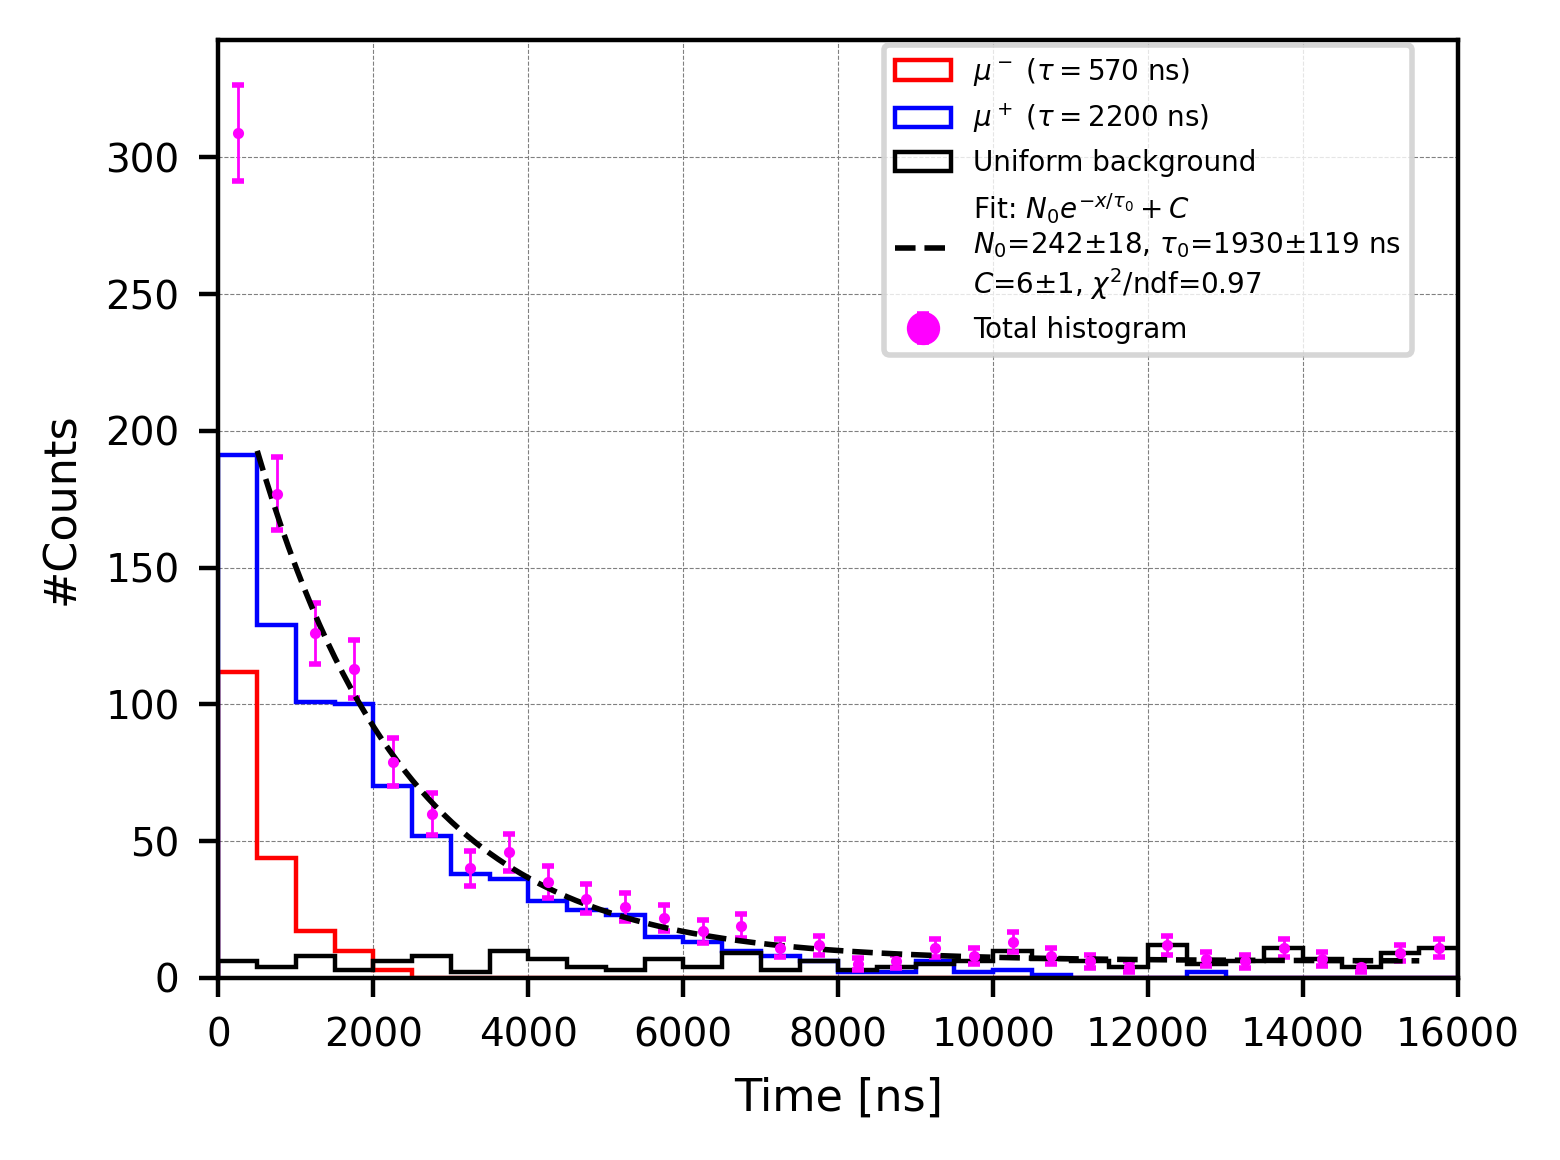


Fitted parameters:
  N0    = 241.7 ± 17.7
  tau0  = 1930 ± 119 ns
  C     = 6.2 ± 0.8
  Chi² / ndf = 26.1 / 27 = 0.97

Bin Center [ns]   Counts   Error
     250.0         309     17.58
     750.0         177     13.30
    1250.0         126     11.22
    1750.0         113     10.63
    2250.0          79      8.89
    2750.0          60      7.75
    3250.0          40      6.32
    3750.0          46      6.78
    4250.0          35      5.92
    4750.0          29      5.39
    5250.0          26      5.10
    5750.0          22      4.69
    6250.0          17      4.12
    6750.0          19      4.36
    7250.0          11      3.32
    7750.0          12      3.46
    8250.0           5      2.24
    8750.0           6      2.45
    9250.0          11      3.32
    9750.0           8      2.83
   10250.0          13      3.61
   10750.0           8      2.83
   11250.0           6      2.45
   11750.0           4      2.00
   12250.0          12      3.46
   12750.0           7

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Generate samples------------------------------------------
np.random.seed(42)

tau_d = 2200  # long-lived
tau = 570     # short-lived
Np = 1200 * 0.72 # The N_+0
Nn = 1000 * 0.72 # N_-0
n_C = 200

#From the point of generator, it is the same as previous simulation------

#Here is the generator, total num of each generator. For above formula, if we do the integral, 
#we can find for mu^+ term, the total is N_+0, for mu^-, it is (N_-0 * tau / tau_d) 
#The ratio between N_n / N_p is 0.26 / 1.2 = 0.217
N_p = int(np.floor(Np)) 
N_n = int(np.floor(Nn * tau / tau_d)) # (N_- * tau)

print("#mu^+: ", N_p)
print("#mu^-: ", N_n,  "({:.2f}%)".format(N_n/N_p*100))

# Generate samples--------
samples_A = np.random.exponential(scale=tau, size=N_n) # mu^-
samples_B = np.random.exponential(scale=tau_d, size=N_p) # mu^+
samples_C = np.random.uniform(0, 16000, n_C)







# Plot the histograms------------------------------------
plt.figure(figsize=(4, 3), dpi=400)

# Define a common bin width
bin_width = 500  # ns
range_min = 0
range_max = 16000
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Compute histogram values
hist_A, bin_edges_A = np.histogram(samples_A, bins=bins, range=(range_min, range_max))
hist_B, bin_edges_B = np.histogram(samples_B, bins=bins, range=(range_min, range_max))
hist_C, bin_edges_C = np.histogram(samples_C, bins=bins, range=(range_min, range_max))

# Sum of all histograms
sum_hist = hist_A + hist_B + hist_C
bin_centers = (bin_edges_A[:-1] + bin_edges_A[1:]) / 2
sum_err = np.sqrt(sum_hist)

# Define the fitting function
def exp_func(t, N0, tau0, C):
    return N0 * np.exp(-t / tau0) + C

# Fit only within [500, 15500] and where counts > 0
fit_mask = (bin_centers >= 500) & (bin_centers <= 15500) & (sum_hist > 0)
fit_x = bin_centers[fit_mask]
fit_y = sum_hist[fit_mask]
fit_err = sum_err[fit_mask]

# Initial guess for parameters
initial_guess = [8000, 1000, 100]  # N0, tau0, C
popt, pcov = curve_fit(exp_func, fit_x, fit_y, p0=initial_guess, sigma=fit_err, absolute_sigma=True)
N0_fit, tau0_fit, C_fit = popt
N0_err, tau0_err, C_err = np.sqrt(np.diag(pcov))

# Compute chi-squared---------------
fit_model = exp_func(fit_x, *popt)
chi2 = np.sum(((fit_y - fit_model) / fit_err) ** 2)
ndf = len(fit_y) - len(popt)
chi2_ndf = chi2 / ndf

# Draw histograms of components and total
plt.hist(samples_A, bins=bins, histtype='step', color='red', linewidth=0.8, label='$\\mu^-$ ($\\tau = 570$ ns)')
plt.hist(samples_B, bins=bins, histtype='step', color='blue', linewidth=0.8, label='$\\mu^+$ ($\\tau = 2200$ ns)')
plt.hist(samples_C, bins=bins, histtype='step', color='black', linewidth=0.8, label='Uniform background')
plt.errorbar(bin_centers, sum_hist, yerr=sum_err, fmt='o', color='magenta',
             markersize=1, elinewidth=0.5, capsize=1.0, label='Total histogram')

# Plot the fitted curve in [500, 15500] only
x_fit_line = np.linspace(500, 15500, 300)
y_fit_line = exp_func(x_fit_line, *popt)
plt.plot(x_fit_line, y_fit_line, 'k--', linewidth=1.0,
         label=f'Fit: $N_0 e^{{-x/\\tau_0}} + C$\n'
               f'$N_0$={N0_fit:.0f}±{N0_err:.0f}, $\\tau_0$={tau0_fit:.0f}±{tau0_err:.0f} ns\n'
               f'$C$={C_fit:.0f}±{C_err:.0f}, $\\chi^2$/ndf={chi2_ndf:.2f}')


# Axes settings-------------------
plt.xlim(0, 16000)
#plt.ylim(0.9, 4000)
#plt.yscale('log')
plt.xlabel('Time [ns]', fontsize=8)
plt.ylabel('#Counts', fontsize=8)
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.75, 1.01), fontsize=8, markerscale=5, ncol=1, prop={'size': 5})
plt.tight_layout()
plt.show()

# Print fit results----------
print(f"\nFitted parameters:")
print(f"  N0    = {N0_fit:.1f} ± {N0_err:.1f}")
print(f"  tau0  = {tau0_fit:.0f} ± {tau0_err:.0f} ns")
print(f"  C     = {C_fit:.1f} ± {C_err:.1f}")
print(f"  Chi² / ndf = {chi2:.1f} / {ndf} = {chi2_ndf:.2f}")

# Print bin center, count, and error----------
print("\nBin Center [ns]   Counts   Error")
for center, count, error in zip(bin_centers, sum_hist, sum_err):
    print(f"{center:10.1f}      {count:6d}   {error:7.2f}")



print("mu⁻ histogram counts:", hist_A)

